In [2]:
# Importing important libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# To make plots look better
sns.set_style("whitegrid")

In [6]:
# Step 1: Load the data
df = pd.read_excel("SuperStore.xlsx")

In [8]:
# Step 2: Look at basic details
print("First 10 rows:")
print(df.head(10))

First 10 rows:
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0    2718  CA-2016-100006 2016-09-07 2016-09-13  Standard Class    DK-13375   
1    6288  CA-2016-100090 2016-07-08 2016-07-12  Standard Class    EB-13705   
2    6289  CA-2016-100090 2016-07-08 2016-07-12  Standard Class    EB-13705   
3    9515  CA-2016-100293 2016-03-14 2016-03-18  Standard Class    NF-18475   
4    3084  CA-2016-100328 2016-01-28 2016-02-03  Standard Class    JC-15340   
5    3836  CA-2016-100363 2016-04-08 2016-04-15  Standard Class    JM-15655   
6    3837  CA-2016-100363 2016-04-08 2016-04-15  Standard Class    JM-15655   
7    9441  CA-2016-100391 2016-05-25 2016-05-29  Standard Class    BW-11065   
8    6569  CA-2016-100678 2016-04-18 2016-04-22  Standard Class    KM-16720   
9    6570  CA-2016-100678 2016-04-18 2016-04-22  Standard Class    KM-16720   

      Customer Name      Segment Country/Region           City  ...  \
0       Dennis Kane     Consumer  United Sta

In [22]:
print("\nShape of data:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nInfo about the data:")
print(df.info())


Shape of data:
(9983, 21)

Column names:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

Info about the data:
<class 'pandas.core.frame.DataFrame'>
Index: 9983 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9983 non-null   int64         
 1   Order ID        9983 non-null   object        
 2   Order Date      9983 non-null   datetime64[ns]
 3   Ship Date       9983 non-null   datetime64[ns]
 4   Ship Mode       9983 non-null   object        
 5   Customer ID     9983 non-null   object        
 6   Customer Name   9983 non-null   object        
 7   Segment         9983 non-null   objec

In [24]:
# Step 3: Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [20]:
# Removing missing values if any
df = df.dropna()
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [26]:
# Step 4: Checkin for duplicates
print("\nDuplicate rows:")
print(df.duplicated().sum())

# Removing duplicate rows
df = df.drop_duplicates()


Duplicate rows:
0


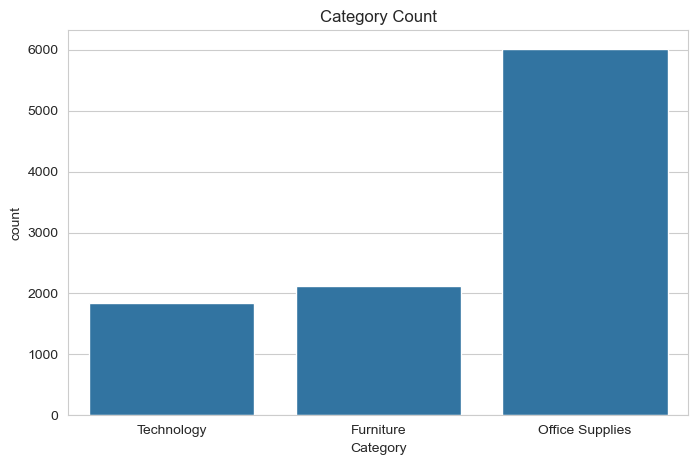

In [28]:
# Step 5: Visualizations

# 5.1 - Bar charts

# Category wise count
plt.figure(figsize=(8,5))
sns.countplot(x='Category', data=df)
plt.title('Category Count')
plt.show()


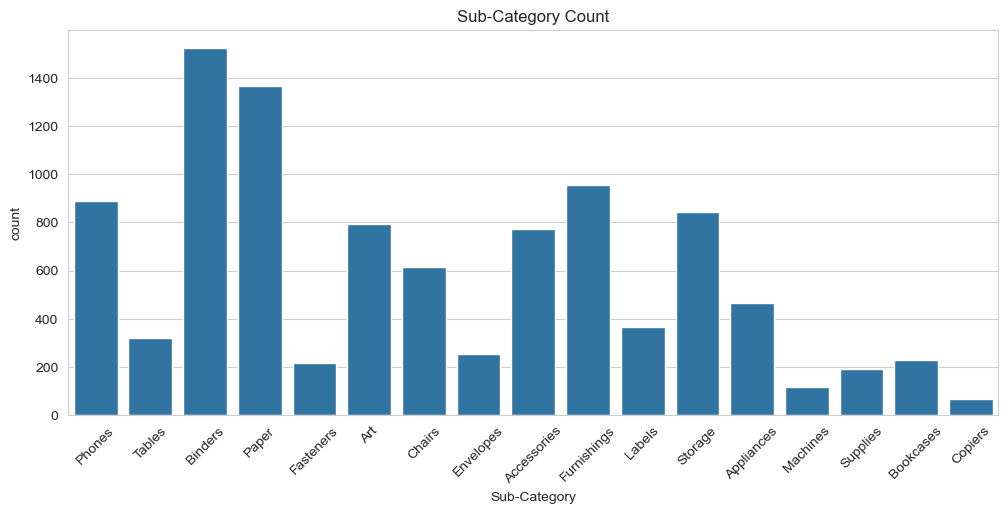

In [30]:
# Sub-Category wise count
plt.figure(figsize=(12,5))
sns.countplot(x='Sub-Category', data=df)
plt.title('Sub-Category Count')
plt.xticks(rotation=45)
plt.show()

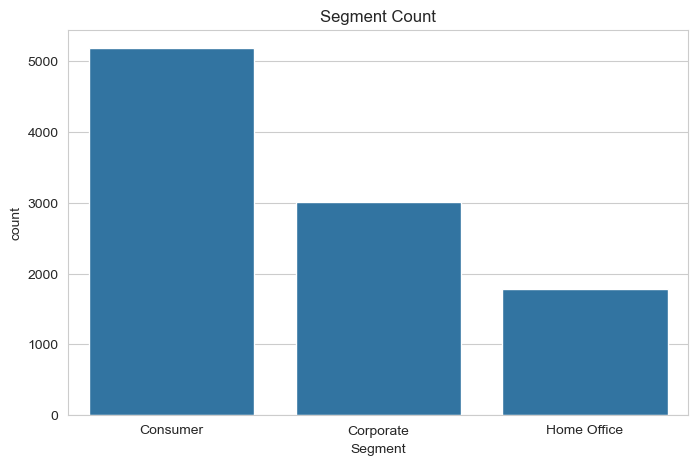

In [32]:
# Segment
plt.figure(figsize=(8,5))
sns.countplot(x='Segment', data=df)
plt.title('Segment Count')
plt.show()

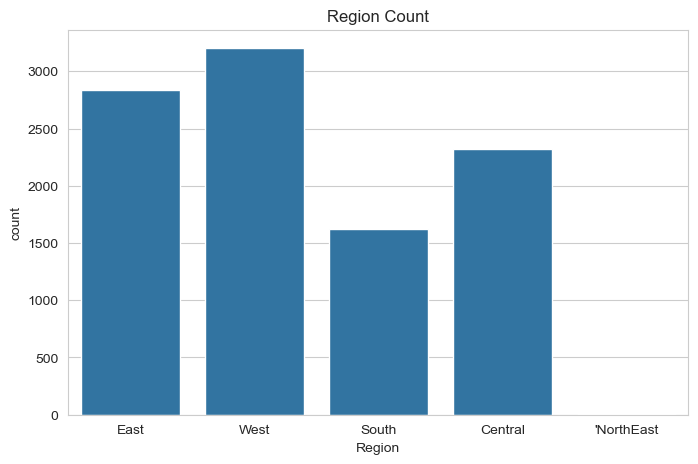

In [34]:
# Region
plt.figure(figsize=(8,5))
sns.countplot(x='Region', data=df)
plt.title('Region Count')
plt.show()

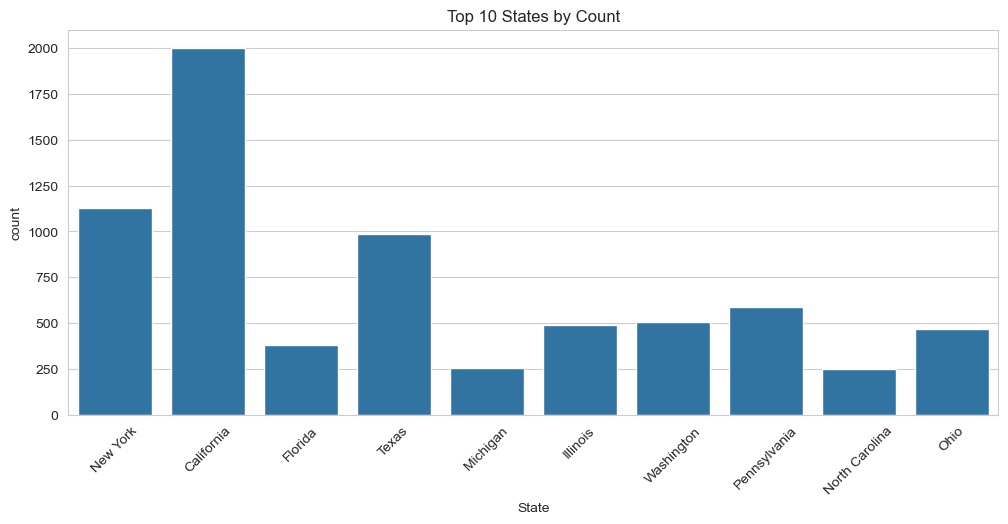

In [36]:
# Top 10 states by count
top_states = df['State'].value_counts().head(10).index
plt.figure(figsize=(12,5))
sns.countplot(data=df[df['State'].isin(top_states)], x='State')
plt.title('Top 10 States by Count')
plt.xticks(rotation=45)
plt.show()

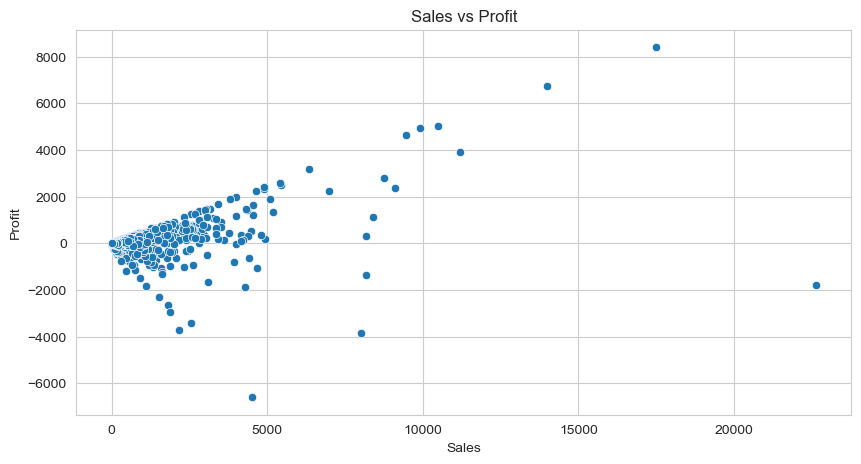

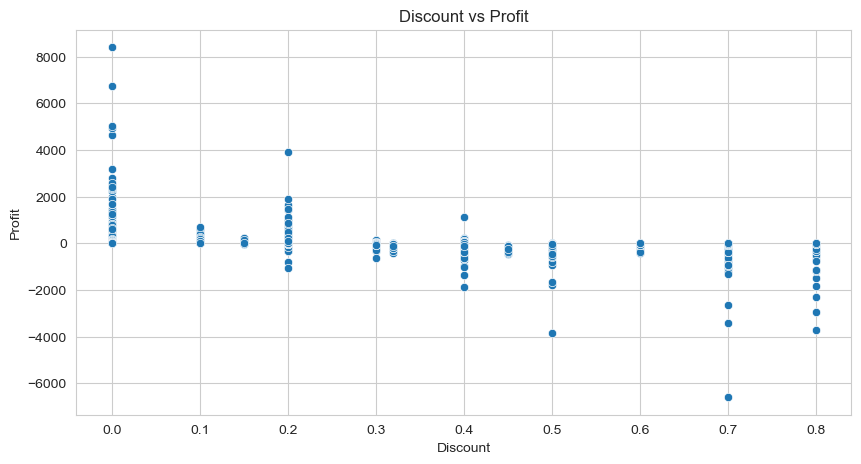

In [38]:
# 5.2 - Scatter plots

# Sales vs Profit
plt.figure(figsize=(10,5))
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs Profit')
plt.show()

# Discount vs Profit
plt.figure(figsize=(10,5))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title('Discount vs Profit')
plt.show()

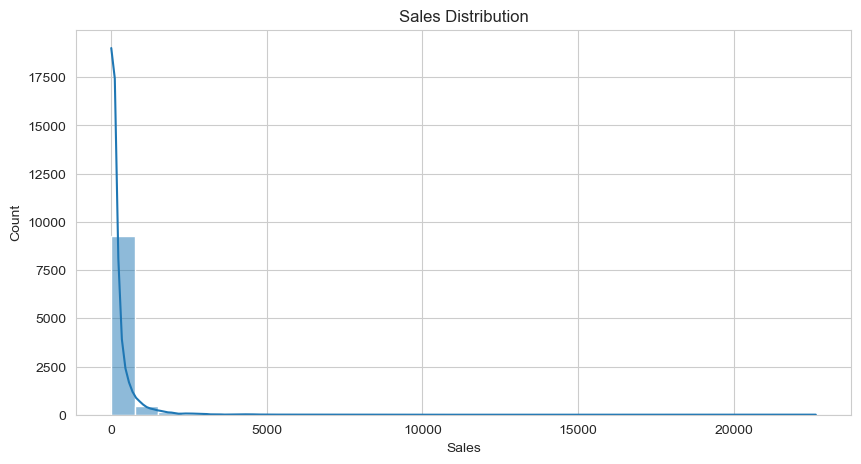

In [50]:
# 5.3 - Histograms

plt.figure(figsize=(10,5))
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title('Sales Distribution')
plt.show()

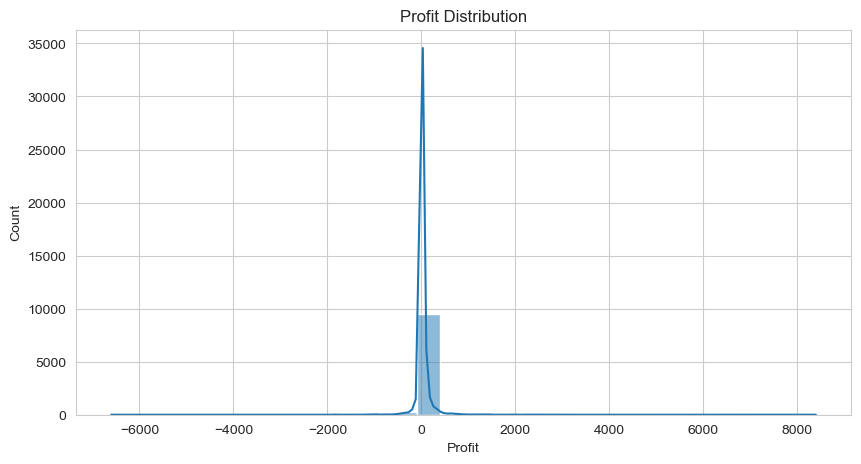

In [52]:
plt.figure(figsize=(10,5))
sns.histplot(df['Profit'], bins=30, kde=True)
plt.title('Profit Distribution')
plt.show()

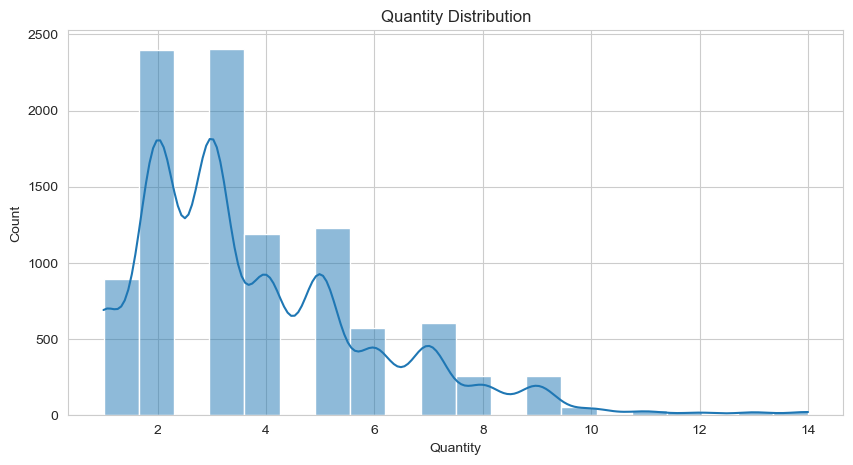

In [54]:
plt.figure(figsize=(10,5))
sns.histplot(df['Quantity'], bins=20, kde=True)
plt.title('Quantity Distribution')
plt.show()

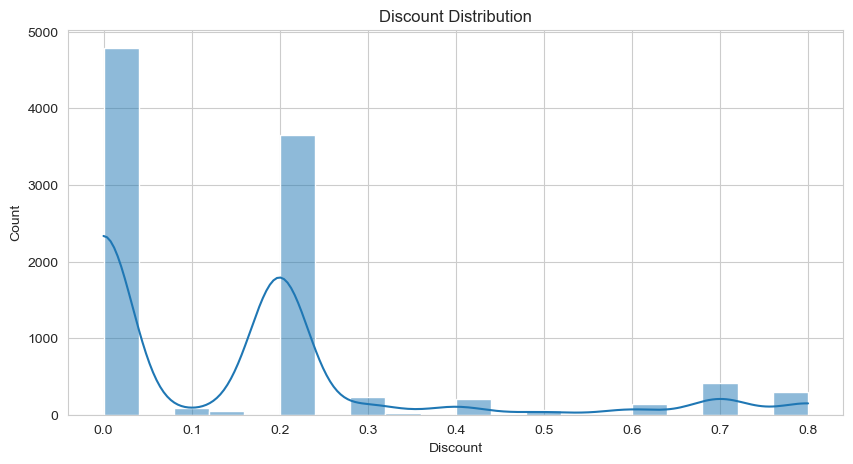

In [56]:
plt.figure(figsize=(10,5))
sns.histplot(df['Discount'], bins=20, kde=True)
plt.title('Discount Distribution')
plt.show()

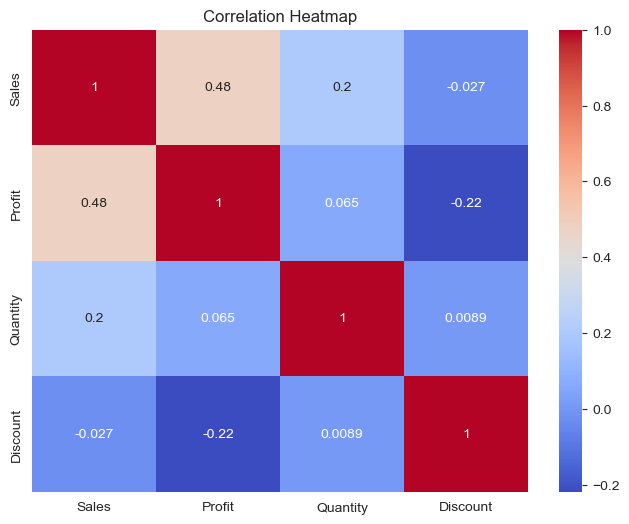

In [58]:
# 5.4 - Heatmap (correlation)
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales', 'Profit', 'Quantity', 'Discount']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

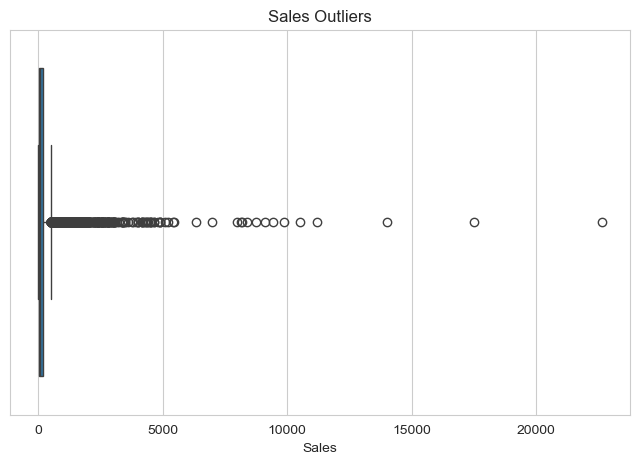

In [44]:
# Step 6: Outlier Detection

# Sales boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Sales'])
plt.title('Sales Outliers')
plt.show()

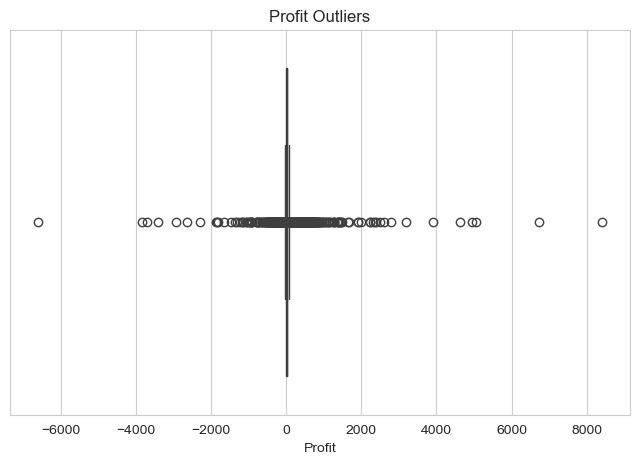

In [46]:
# Profit boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Profit'])
plt.title('Profit Outliers')
plt.show()

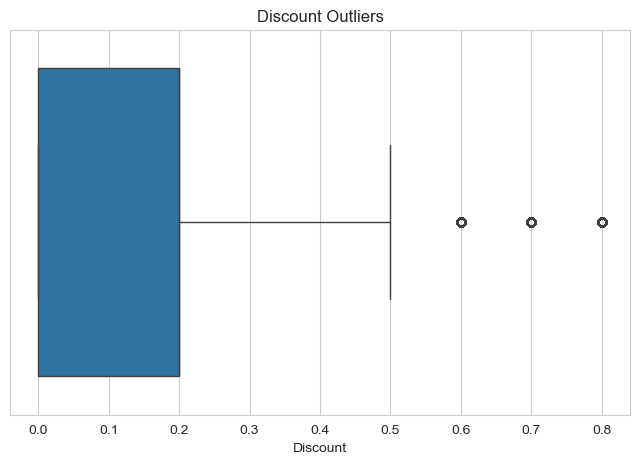

In [48]:
# Discount boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Discount'])
plt.title('Discount Outliers')
plt.show()